In [12]:
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from matplotlib.colors import XKCD_COLORS

In [ ]:
# --- Configuration ---
config = {
    'data_dir': "../derivatives",
    'raw_dir': "../ds000224",
    'roi_mask_path': "./Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'output_dir_name': 'datasets', # Name for subdirectory
    'output_suffix': 'roi-fef_encoding-categorical_desc-simp_model_1.csv',
    'nilearn_defaults': {
         'standardize': 'zscore_sample',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2.2
     },
     'hrf_model': 'spm'
}

# --- Usage Example in loop ---
# Instead of:
# p_brain = os.path.join(data_path, subj_pref+sub, ...)
# You'd use:
sub_id = f"{config['subj_prefix']}{sub}"
ses_id = f"{config['sess_prefix']}{ses}"
task_id = config['task_label']
space_id = config['space_label']

p_brain = os.path.join(config['data_dir'], sub_id, ses_id, 'func',
                       f"{sub_id}_{ses_id}_{task_id}_{space_id}_{config['bold_suffix']}")
# ... and so on for other paths and parameters

In [ ]:
import logging

# --- Basic Setup (do this once at the start) ---
logging.basicConfig(level=logging.INFO, # Set minimum level to show
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    # filename='pipeline.log', # Uncomment to log to a file
                    # filemode='w' # 'w' to overwrite, 'a' to append
                   )

# --- Usage Example ---
logging.info(f"Starting processing for Subject {sub}, Session {ses}")

if not os.path.isfile(p_brain):
    logging.warning(f"Brain file not found for {sub}, {ses}. Skipping.") # Use WARNING for skips
    continue

try:
    bold_img = skull_strip(p_brain, p_mask)
    logging.debug("Skull stripping successful.") # DEBUG for detailed steps
except Exception as e:
    logging.error(f"Error during skull stripping for {sub}, {ses}: {e}") # ERROR for failures
    continue # Or handle error differently

# ... later ...
logging.info(f"Finished Subject {sub}, Session {ses}")

In [3]:
fdf = pd.read_csv("./full_fef_dataset1.csv", header=0, index_col=0)
fdf.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v111,v112,v113,v114,v115,v116,v117,v118,v119,target
0,0.0,-1.357829e-07,-1.386015e-07,9.921290e-08,2.399383e-07,-2.166948e-07,-1.489032e-07,-1.082097e-07,3.818681e-08,2.981593e-07,...,2.133059e-08,3.909145e-07,-1.033122e-07,-2.027137e-08,1.377441e-07,-2.207919e-07,-4.686958e-09,-1.665084e-07,-4.525186e-07,nontask
1,2.2,8.909464e-07,9.094406e-07,-6.509904e-07,-1.574367e-06,1.421854e-06,9.770358e-07,7.100235e-07,-2.505648e-07,-1.956388e-06,...,-1.399618e-07,-2.565006e-06,6.778881e-07,1.330117e-07,-9.038149e-07,1.448738e-06,3.075332e-08,1.092554e-06,2.969224e-06,nontask
2,4.4,-3.170183e-06,-3.235989e-06,2.316367e-06,5.601944e-06,-5.059267e-06,-3.476508e-06,-2.526419e-06,8.915643e-07,6.961257e-06,...,4.980149e-07,9.126853e-06,-2.412075e-06,-4.732848e-07,3.215972e-06,-5.154925e-06,-1.094273e-07,-3.887546e-06,-1.056515e-05,nontask
3,6.6,8.196495e-06,8.366638e-06,-5.988958e-06,-1.448381e-05,1.308072e-05,8.988498e-06,6.532048e-06,-2.305136e-06,-1.799831e-05,...,-1.287616e-06,-2.359745e-05,6.236410e-06,1.223676e-06,-8.314883e-06,1.332804e-05,2.829237e-07,1.005124e-05,2.731616e-05,nontask
4,8.8,-1.727009e-05,-1.762858e-05,1.261879e-05,3.051751e-05,-2.756119e-05,-1.893885e-05,-1.376308e-05,4.856943e-06,3.792259e-05,...,2.713018e-06,4.972003e-05,-1.314017e-05,-2.578297e-06,1.751953e-05,-2.808230e-05,-5.961229e-07,-2.117804e-05,-5.755540e-05,nontask


In [4]:
fdf.target.value_counts()

target
mixed      4250
indoor     3145
outdoor    3018
nontask    1324
Name: count, dtype: int64

At this point, we do not know the answers to the following questions:
1. Do all the voxels contain relevant information?
2. Is this the best way of encoding the hemodynamic response function convolved with the experimental design into classes?
3. How do I incorporate the temporal relationships into this dataset in a meaningful way?

As seen above, the target column is not very well balanced. We will start by classifying this dataset as-is.

In [5]:
# First, let's convert the strings in the target column into categorical numerics.
fdf['target_numeric'] = fdf['target'].map({'mixed':4, 'outdoor':3, 'indoor':2, 'nontask':1})
fdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11737 entries, 0 to 11736
Columns: 123 entries, scan_time to target_numeric
dtypes: float64(121), int64(1), object(1)
memory usage: 11.1+ MB


---

In [6]:
x = fdf.drop(['target', 'target_numeric', 'scan_time'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = fdf['target_numeric']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
model_1 = KNeighborsClassifier(n_neighbors=500).fit(X_train,y_train)
y_m1 = model_1.predict(X_test)
acc_m1 = accuracy_score(y_test, y_m1)

In [9]:
acc_m1

0.3222600795002839

In [10]:
print(classification_report(y_test, y_m1, zero_division=True))

              precision    recall  f1-score   support

           1       0.22      0.70      0.34       379
           2       0.75      0.00      0.01       941
           3       1.00      0.00      0.00       964
           4       0.37      0.70      0.49      1238

    accuracy                           0.32      3522
   macro avg       0.59      0.35      0.21      3522
weighted avg       0.63      0.32      0.21      3522



This accuracy isn't unexpected, and we know that the model is not learning about indoor vs outdoor--not really. Let's actually try a bunch of values of k to discover what value works best. We'll print the classification report for the best value.

In [13]:
model2 = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(5,200,5), 
              'weights': ['uniform', 'distance'], 
              'metric': ['euclidean', 'manhattan']
             }
grid_search = GridSearchCV(estimator=model2, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 156 candidates, totalling 780 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 5, ...85, 190, 195]), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(105)


In [14]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': np.int64(105), 'weights': 'uniform'}
Best CV Score: 0.3641


In [15]:
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Test Set Accuracy: {test_acc:.4f}")

Test Set Accuracy: 0.3509


In [17]:
print(classification_report(y_test, best_model.predict(X_test), zero_division=True))

              precision    recall  f1-score   support

           1       0.34      0.59      0.43       379
           2       0.25      0.08      0.12       941
           3       0.26      0.04      0.07       964
           4       0.37      0.72      0.49      1238

    accuracy                           0.35      3522
   macro avg       0.30      0.36      0.28      3522
weighted avg       0.30      0.35      0.27      3522



As it turns out, we can't really get better than about 35% accuracy.  Before we try different models, let's see if we can visualize our data by reducing dimensions.

-----------------------------

Let's do some dimensionality reduction. 

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA()
pca_x_norm = pca.fit_transform(x)

In [20]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

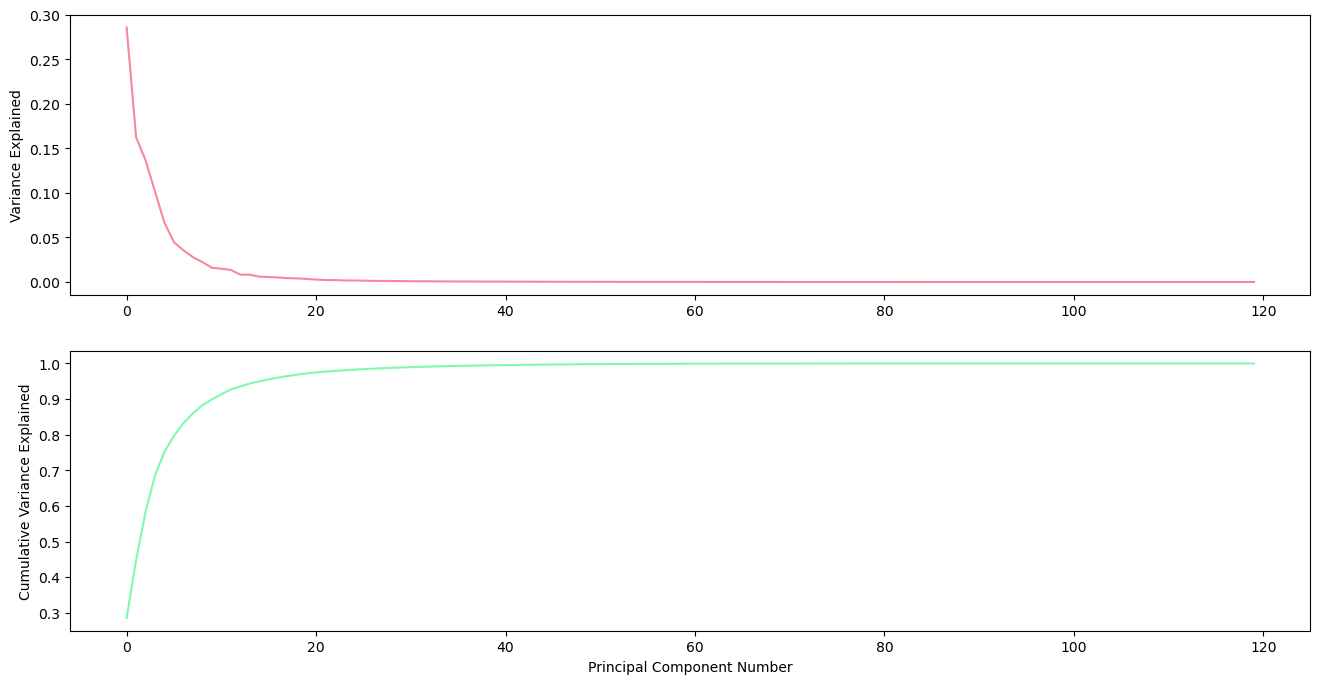

In [23]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

Looks like there are 15 principal components one needs to explain most of the variance in the data.

In [25]:
cum_exp_var[15]

np.float64(0.9553028487214085)

In [26]:
np.savetxt('brain_pca.csv', pca_x_norm[:,0:15], delimiter=',', fmt='%f')

Alright, so now we have shrunk our entire FEF into a bunch of principal components.

---

Now let's make an attempt at using the same model, but with the PCs.  This will give us the same result but is still worth doing just to make sure.

In [ ]:
np.loadtxt('brain_pca.csv') # need to actually save this to variable and format if necessary--just have it here for now

In [27]:
X_train, X_test, y_train, y_test = train_test_split(pca_x_norm[:,0:15], y, test_size=0.3, random_state=42)

In [28]:
model_2 = KNeighborsClassifier(n_neighbors=79).fit(X_train,y_train)
y_m2 = model_2.predict(X_test)
acc_m2 = accuracy_score(y_test, y_m2)

In [29]:
acc_m2

0.3642816581487791

Alright, so I take that back. Clearly, it helped the algorithm somehow. However, for thoroughness, let's do a grid search.

In [30]:
model3 = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(5,500,5), 
              'weights': ['uniform', 'distance'], 
              'metric': ['euclidean', 'manhattan']
             }
grid_search = GridSearchCV(estimator=model3, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 396 candidates, totalling 1980 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 5, ...85, 490, 495]), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(150)


In [31]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': np.int64(150), 'weights': 'uniform'}
Best CV Score: 0.3834


In [32]:
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Test Set Accuracy: {test_acc:.4f}")

Test Set Accuracy: 0.3705


Well, what do you know?  Let's see if we can visualize this.  Let's use some more dimension reduction methods.

In [35]:
from sklearn.manifold import TSNE
import plotly.express as px

In [37]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(pca_x_norm[:,0:15])

In [38]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time']

In [41]:
fig.show(renderer="iframe")
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Time', opacity=0.7, size_max=5, title="3D t-SNE of Brain States")
fig.show()

In [43]:
tsne_df['Target'] = fdf['target']
fig.show(renderer="iframe")
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Target', opacity=0.7, size_max=5, title="3D t-SNE of Brain States")
fig.show()

Well, well, well.